<a href="https://colab.research.google.com/github/KoAlbert/SD_Textual_Inversion/blob/main/%E3%80%8CSD_Textual_Inversion%E3%80%8D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Perform "Textual Inversion" on Stable Diffusion

ref: https://huggingface.co/docs/diffusers/main/en/training/text_inversion



## Setup 🪓

In [ ]:
# Check the GPU
!nvidia-smi

In [ ]:
# Install dependencies.
#!pip install xformers bitsandbytes transformers accelerate -q
!pip install diffusers accelerate transformers

Make sure to install `diffusers` from `main`.

In [ ]:
!pip install git+https://github.com/huggingface/diffusers.git -q

Download the script of Textual Inversion.

In [ ]:
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/textual_inversion/textual_inversion.py


In [ ]:
#!export MODEL_NAME="runwayml/stable-diffusion-v1-5"
#!export INSTANCE_DIR="path-to-instance-images"
#!export OUTPUT_DIR="path-to-save-model"

## Dataset 🐶

Download and Preview the images:

In [ ]:
from PIL import Image

def image_grid(imgs, rows, cols, resize=256):
    assert len(imgs) == rows * cols

    if resize is not None:
        imgs = [img.resize((resize, resize)) for img in imgs]
    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid

In [ ]:
import glob
from huggingface_hub import snapshot_download

local_dir = "./cat_toy_example"
snapshot_download(
    "diffusers/cat_toy_example", local_dir=local_dir, repo_type="dataset", ignore_patterns=".gitattributes"
)

imgs = [Image.open(path) for path in glob.glob("./cat_toy_example/*.jpeg")]
image_grid(imgs, 1, 6)

# Alex 2024/06/27.
# After downloading images, there might be a hidden folder name huggingface (./cat_toy_example/.huggingface). it needs to be deleted to prevent the subsequent error
!rm -r ./cat_toy_example/.*

## Prep for training 💻

Initialize `accelerate`:

In [ ]:
!accelerate config default

Make sure to log into [your Hugging Face account](https://huggingface.co/) and pass [your access token](https://huggingface.co/docs/hub/security-tokens) so that we can push the trained checkpoints to the Hugging Face Hub: Please remember to use "write" token of your huggingface account and you need to create it by youself. **However, if you don't want to push the results to Hugging Face, you don't need to log in and you can simple ignore this step!**

In [ ]:
!huggingface-cli login

## Train! 🔬



# Please remind me that the original setting:
# -max_train_steps=3000
# We need at least 300 steps to achieve the best results

In [ ]:
#!/usr/bin/env bash
#!export MODEL_NAME="runwayml/stable-diffusion-v1-5"
#!export DATA_DIR="./cat_toy_example"

!accelerate launch textual_inversion.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="./cat_toy_example" \
  --learnable_property="object" \
  --placeholder_token="<cat-toy>" \
  --initializer_token="toy" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=10 \
  --learning_rate=5.0e-04 --scale_lr \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --output_dir="textual_inversion_cat" \
  #--push_to_hub

Let's generate some images with it!

## Inference 🐕

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, use_safetensors=True).to("cuda")

pipe.load_textual_inversion("./textual_inversion_cat")


# from diffusers import DiffusionPipeline
# import torch

# from diffusers import DiffusionPipeline, AutoencoderKL

# vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
# pipe = DiffusionPipeline.from_pretrained(
#     "stabilityai/stable-diffusion-xl-base-1.0",
#     vae=vae, torch_dtype=torch.float16, variant="fp16",
#     use_safetensors=True
# )
# pipe.load_lora_weights("./textual_inversion_cat")

# _ = pipe.to("cuda")

In [ ]:
prompt = "A photo of <cat-toy>"

image = pipe(prompt=prompt, num_inference_steps=50).images[0]
image

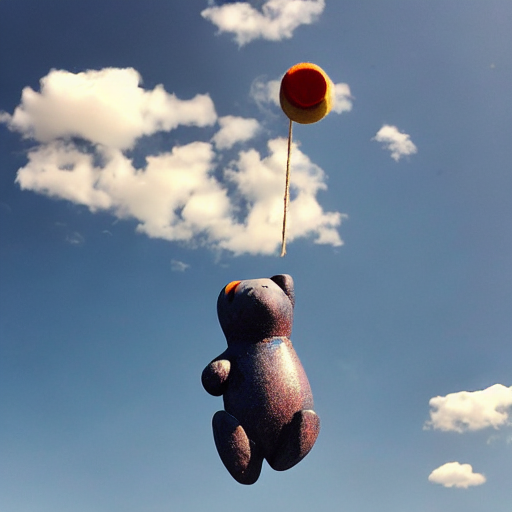